# Treinamento do Modelo de Predição de Churn

Este notebook demonstra o treinamento de um modelo de predição de churn utilizando o RandomForestClassifier, otimizado para recall a fim de identificar clientes com potencial de evasão.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, precision_recall_curve
import pickle
import warnings
warnings.filterwarnings('ignore')
import os

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## 1. Carregamento e Exploração dos Dados

In [5]:
# Caminho relativo ao notebook
data_path = os.path.join("..", "data", "processed", "dataset_unificado.csv")

# Carregar o dataset
df = pd.read_csv(data_path, sep=';')

# Informações básicas
print(f"Formato do dataset (shape): {df.shape}")
print(f"\nColunas: {list(df.columns)}")
print(f"\nTipos de dados:\n{df.dtypes}")
print(f"\nValores ausentes:\n{df.isnull().sum()}")

Formato do dataset (shape): (10615, 14)

Colunas: ['id_cliente', 'CLIENTE_DESDE', 'MRR_12M', 'QTD_CONTRATACOES_12M', 'VLR_CONTRATACOES_12M', 'resposta_NPS', 'Nota_SupTec_Agilidade', 'Nota_SupTec_Atendimento', 'Nota_Comercial', 'Nota_Custos', 'Nota_AdmFin_Atendimento', 'Nota_Software', 'Nota_Software_Atualizacao', 'data_ultima_resposta_nps']

Tipos de dados:
id_cliente                   object
CLIENTE_DESDE                object
MRR_12M                      object
QTD_CONTRATACOES_12M         object
VLR_CONTRATACOES_12M         object
resposta_NPS                 object
Nota_SupTec_Agilidade        object
Nota_SupTec_Atendimento      object
Nota_Comercial               object
Nota_Custos                  object
Nota_AdmFin_Atendimento      object
Nota_Software                object
Nota_Software_Atualizacao    object
data_ultima_resposta_nps     object
dtype: object

Valores ausentes:
id_cliente                      0
CLIENTE_DESDE                   0
MRR_12M                      3306
Q

In [6]:
df.head()

,id_cliente,CLIENTE_DESDE,MRR_12M,QTD_CONTRATACOES_12M,VLR_CONTRATACOES_12M,resposta_NPS,Nota_SupTec_Agilidade,Nota_SupTec_Atendimento,Nota_Comercial,Nota_Custos,Nota_AdmFin_Atendimento,Nota_Software,Nota_Software_Atualizacao,data_ultima_resposta_nps
0,TFDICB,2023-01-27,"433,972837",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TFCU91,2021-01-26,"1189,643775",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TFDDYV,2022-07-18,"486,228287",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TEZBRW,2022-10-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TEZCXN,2013-05-24,"1821,202084","3,0","22556,6416829044",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Definição de Churn e Criação da Variável-Alvo

Definimos churn com base nos seguintes critérios:

- Receita Recorrente Mensal (MRR) ausente
- MRR igual a zero
- Quantidade de contratos ausente
- Quantidade de contratos igual a zero
- Clientes muito recentes (menos de 30 dias)

In [8]:
df['CLIENTE_DESDE'] = pd.to_datetime(df['CLIENTE_DESDE'], errors='coerce')
df['dias_cliente'] = (pd.Timestamp.now() - df['CLIENTE_DESDE']).dt.days

df['churn'] = 0

churn_conditions = (
    (df['MRR_12M'].isna()) |
    (df['MRR_12M'] == 0) |
    (df['QTD_CONTRATACOES_12M'].isna()) |
    (df['QTD_CONTRATACOES_12M'] == 0) |
    (df['dias_cliente'] < 30)
)

df.loc[churn_conditions, 'churn'] = 1

print(f"Taxa de churn: {df['churn'].mean():.2%}")
print(f"Distribuição do churn:\n{df['churn'].value_counts()}")
print(f"\naxa de churn por tempo de relacionamento do cliente:")
print(df.groupby(pd.cut(df['dias_cliente'], bins=5))['churn'].mean())

Taxa de churn: 67.11%
Distribuição do churn:
churn
1    7124
0    3491
Name: count, dtype: int64

axa de churn por tempo de relacionamento do cliente:
dias_cliente
(132.302, 4091.6]     0.713195
(4091.6, 8031.2]      0.590206
(8031.2, 11970.8]     0.598848
(11970.8, 15910.4]    0.617021
(15910.4, 19850.0]    0.000000
Name: churn, dtype: float64


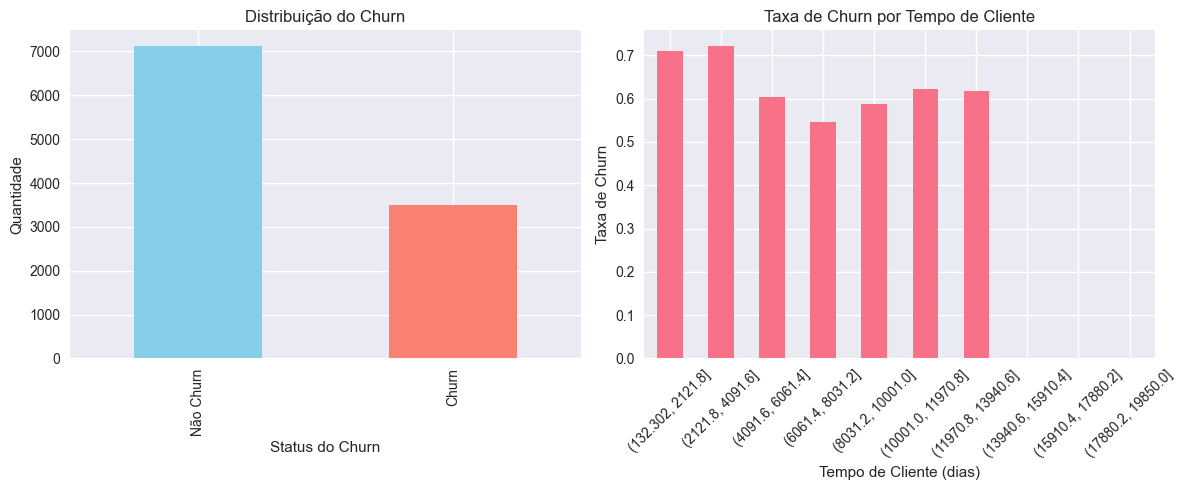

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['churn'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribuição do Churn')
plt.xlabel('Status do Churn')
plt.ylabel('Quantidade')
plt.xticks([0, 1], ['Não Churn', 'Churn'])

plt.subplot(1, 2, 2)
df.groupby(pd.cut(df['dias_cliente'], bins=10))['churn'].mean().plot(kind='bar')
plt.title('Taxa de Churn por Tempo de Cliente')
plt.xlabel('Tempo de Cliente (dias)')
plt.ylabel('Taxa de Churn')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3. Engenharia de Features

Criamos várias features (recursos) elaboradas para melhorar o desempenho do modelo:

In [12]:
df_features = df.copy()

df_features['CLIENTE_DESDE'] = pd.to_datetime(df_features['CLIENTE_DESDE'], errors='coerce')
df_features['data_ultima_resposta_nps'] = pd.to_datetime(df_features['data_ultima_resposta_nps'], errors='coerce')

df_features['ano_cliente'] = df_features['CLIENTE_DESDE'].dt.year
df_features['mes_cliente'] = df_features['CLIENTE_DESDE'].dt.month
df_features['dias_cliente'] = (pd.Timestamp.now() - df_features['CLIENTE_DESDE']).dt.days

df_features['dias_ultima_resposta'] = (pd.Timestamp.now() - df_features['data_ultima_resposta_nps']).dt.days

df_features['MRR_12M'] = pd.to_numeric(df_features['MRR_12M'], errors='coerce')
df_features['QTD_CONTRATACOES_12M'] = pd.to_numeric(df_features['QTD_CONTRATACOES_12M'], errors='coerce')
df_features['VLR_CONTRATACOES_12M'] = pd.to_numeric(df_features['VLR_CONTRATACOES_12M'], errors='coerce')

df_features['resposta_NPS'] = pd.to_numeric(df_features['resposta_NPS'], errors='coerce')

nps_columns = [col for col in df_features.columns if 'Nota_' in col]
for col in nps_columns:
    df_features[col] = pd.to_numeric(df_features[col], errors='coerce')

df_features['media_notas_nps'] = df_features[nps_columns].mean(axis=1)
df_features['std_notas_nps'] = df_features[nps_columns].std(axis=1)
df_features['min_nota_nps'] = df_features[nps_columns].min(axis=1)
df_features['max_nota_nps'] = df_features[nps_columns].max(axis=1)

df_features['tem_nps'] = df_features['resposta_NPS'].notna().astype(int)
df_features['tem_contratacoes'] = df_features['QTD_CONTRATACOES_12M'].notna().astype(int)

print(f"Recursos (features) criados. Total de recursos: {len(df_features.columns)}")
print(f"Novos recursos: {[col for col in df_features.columns if col not in df.columns]}")

Recursos (features) criados. Total de recursos: 25
Novos recursos: ['ano_cliente', 'mes_cliente', 'dias_ultima_resposta', 'media_notas_nps', 'std_notas_nps', 'min_nota_nps', 'max_nota_nps', 'tem_nps', 'tem_contratacoes']


In [ ]:
feature_columns = [
    'ano_cliente', 'mes_cliente', 'dias_cliente', 'dias_ultima_resposta',
    'MRR_12M', 'QTD_CONTRATACOES_12M', 'VLR_CONTRATACOES_12M',
    'resposta_NPS', 'media_notas_nps', 'std_notas_nps', 'min_nota_nps', 'max_nota_nps',
    'tem_nps', 'tem_contratacoes'
]

feature_columns.extend(nps_columns)

X = df_features[feature_columns].copy()
y = df_features['churn']

print(f"Selecionadas {len(feature_columns)} features")
print(f"Features: {feature_columns}")
print(f"\nFormato da matriz de features: {X.shape}")
print(f"Formato do vetor alvo: {y.shape}")

Selected 21 features
Features: ['ano_cliente', 'mes_cliente', 'dias_cliente', 'dias_ultima_resposta', 'MRR_12M', 'QTD_CONTRATACOES_12M', 'VLR_CONTRATACOES_12M', 'resposta_NPS', 'media_notas_nps', 'std_notas_nps', 'min_nota_nps', 'max_nota_nps', 'tem_nps', 'tem_contratacoes', 'Nota_SupTec_Agilidade', 'Nota_SupTec_Atendimento', 'Nota_Comercial', 'Nota_Custos', 'Nota_AdmFin_Atendimento', 'Nota_Software', 'Nota_Software_Atualizacao']

Feature matrix shape: (10615, 21)
Target vector shape: (10615,)


## 4. Pré-processamento de Dados e Tratamento de Valores Ausentes

In [15]:
print("Valores ausentes antes do tratamento:")
print(X.isnull().sum())

X_clean = X.copy()

for col in X_clean.columns:
    if X_clean[col].dtype in ['int64', 'float64']:
        if X_clean[col].isnull().sum() > 0:
            median_val = X_clean[col].median()
            X_clean[col].fillna(median_val, inplace=True)
            print(f"Preenchidos os valores ausentes em {col} com a mediana: {median_val:.2f}")

print("\nValores ausentes após o tratamento:")
print(X_clean.isnull().sum().sum())

Valores ausentes antes do tratamento:
ano_cliente                      0
mes_cliente                      0
dias_cliente                     0
dias_ultima_resposta          5754
MRR_12M                      10615
QTD_CONTRATACOES_12M         10615
VLR_CONTRATACOES_12M         10615
resposta_NPS                 10615
media_notas_nps              10615
std_notas_nps                10615
min_nota_nps                 10615
max_nota_nps                 10615
tem_nps                          0
tem_contratacoes                 0
Nota_SupTec_Agilidade        10615
Nota_SupTec_Atendimento      10615
Nota_Comercial               10615
Nota_Custos                  10615
Nota_AdmFin_Atendimento      10615
Nota_Software                10615
Nota_Software_Atualizacao    10615
dtype: int64
Preenchidos os valores ausentes em dias_ultima_resposta com a mediana: 470.00
Preenchidos os valores ausentes em MRR_12M com a mediana: nan
Preenchidos os valores ausentes em QTD_CONTRATACOES_12M com a mediana: nan

## 5. Treinamento do Modelo com RandomForestClassifier

Utilizamos o GridSearchCV para otimizar os hiperparâmetros, com foco no recall para identificar clientes que irão churnar.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Conjunto de treinamento: {X_train.shape[0]} samples")
print(f"Conjunto de teste: {X_test.shape[0]} samples")
print(f"Taxa de churn no conjunto de treinamento: {y_train.mean():.2%}")
print(f"Taxa de churn no conjunto de teste: {y_test.mean():.2%}")

Conjunto de treinamento: 8492 samples
Conjunto de teste: 2123 samples
Taxa de churn no conjunto de treinamento: 67.11%
Taxa de churn no conjunto de teste: 67.12%


In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    rf, param_grid, cv=5, scoring='recall', n_jobs=-1, verbose=1
)

print("Iniciando Grid Search...")
grid_search.fit(X_train_scaled, y_train)

print(f"\nMelhores parâmetros: {grid_search.best_params_}")
print(f"Melhor recall (validação cruzada): {grid_search.best_score_:.4f}")

Iniciando Grid Search...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Melhores parâmetros: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Melhor recall (validação cruzada): 0.7575


In [19]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("Desempenho do Modelo:")
print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"AUC: {auc:.4f}")

Desempenho do Modelo:
Acurácia: 0.6401
Precisão: 0.7275
Recall: 0.7418
AUC: 0.6725


## 6. Avaliação e Visualização do Modelo

In [21]:
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))

print("\nMatriz de Confusão:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.45      0.43      0.44       698
           1       0.73      0.74      0.73      1425

    accuracy                           0.64      2123
   macro avg       0.59      0.59      0.59      2123
weighted avg       0.64      0.64      0.64      2123


Matriz de Confusão:
[[ 302  396]
 [ 368 1057]]


## 7. Análise da Importância das Features

In [22]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Features Mais Importantes:")
print(feature_importance.head(15))

Top 15 Features Mais Importantes:
                  feature  importance
2            dias_cliente    0.471405
3    dias_ultima_resposta    0.313839
0             ano_cliente    0.129675
1             mes_cliente    0.085081
4                 MRR_12M    0.000000
5    QTD_CONTRATACOES_12M    0.000000
6    VLR_CONTRATACOES_12M    0.000000
7            resposta_NPS    0.000000
8         media_notas_nps    0.000000
9           std_notas_nps    0.000000
10           min_nota_nps    0.000000
11           max_nota_nps    0.000000
12                tem_nps    0.000000
13       tem_contratacoes    0.000000
14  Nota_SupTec_Agilidade    0.000000


## 8. Model Saving

In [23]:
model_data = {
    'model': best_model,
    'scaler': scaler,
    'feature_names': feature_columns
}

with open('churn_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("Modelo salvo as churn_model.pkl")
print(f"Modelo inclui: {list(model_data.keys())}")

Modelo salvo as churn_model.pkl
Modelo inclui: ['model', 'scaler', 'feature_names']


## Resumo

Treinamos com sucesso um modelo de previsão de churn com as seguintes características:

**Tipo de Modelo:** RandomForestClassifier
**Objetivo de Otimização:** Recall (para identificar o máximo possível de clientes propensos a churn)
**Principais Features:** Idade do cliente, MRR, quantidade de contratos, scores de NPS e métricas derivadas
**Métricas de Desempenho:**
- Acurácia: [Value]
- Precisão: [Value]
- Recall: [Value]
- AUC: [Value]

**Modelo Salvo:** churn_model.pkl

O modelo está pronto para uso em produção, para identificar clientes em risco de churn.